In [35]:
import os
import tensorflow as tf
import pandas as pd
import sys
sys.path.append(os.path.join('c:\\', *os.getcwd().split('\\')[1:-1]))
from sgcc5 import *

In [36]:
param_bounds = {
    "fts": [0, 175],
    "t": [40, 125],
    "ampc": [0.01, 0.1],
    'ampm': [0,3],
    "ampg": [0.1, 4],
    "ampw": [0.01, 0.08],
    "d": [10, 40],
    "inh_d": [0, 40],
    "inh_w": [0, 3],
}

In [37]:
sgcc = SGCCircuit(param_bounds)

In [38]:
sgcc.initialize_random_parameters(n_v1=2, n_lgn=3,n_sample=100)

In [39]:
## Apply the property independently to each parameter class

def dlgn_scaled(self):
    if self.identify:
        ## apply identifiability constraint (dLGN0<=dLGN1<=dLGN2)
        n_params = self.dlgn_raw.shape[3]
        
        ordered_units = []
        for i in range(n_params):
            leading_unit = self.dlgn_raw[:, :, 0:1, i, ...] # leading dLGN unit
            trailing_offsets = tf.nn.softplus( # values added to consecutive dLGN units (enforce positive vals)
                self.dlgn_raw[:, :, 1:, i, ...]
            ) 

            # get the values of the trailing units by adding the offsets to the leading unit
            trailing_units = leading_unit + tf.cumsum(trailing_offsets, axis=2)
            ordered_units.append(tf.concat([leading_unit, trailing_units], axis=2))

        return tf.concat(ordered_units, axis=3) 
    
    else:
        return self.dlgn_raw

In [40]:
## Apply a learnable permutation structure to the units

n_params = 7

## soft_perm needs to be a trainable variable
soft_perm = tf.Variable(tf.random.normal((7, 2, 3)))

P = tf.tile(
    tf.expand_dims(tf.argsort(soft_perm),axis = 0),
    [sgcc.n_sample,1,1,1]
)

result = tf.stack([
    tf.gather(
        tf.squeeze(sgcc.dlgn_raw[:, :, :, i, ...]), 
        indices=P[:,i], 
        axis=2, batch_dims=2
    )
    for i in range(7)
], axis = 3)[:,:,:,:,None,None]

In [41]:
## Apply the property independently to each parameter class

def dlgn_scaled(self):
    if self.identify: ## apply identifiability constraint (dLGN0<=dLGN1<=dLGN2)
        
        n_params = self.dlgn_raw.shape[3]

        # Get the order permutation
        P = tf.tile(
            tf.expand_dims(tf.argsort(soft_perm),axis = 0),
            [sgcc.n_sample,1,1,1]
        )
        
        # Apply ordered structure
        ordered_units = []
        for i in range(n_params):
            dlgn_permutation = tf.gather(
                tf.squeeze(
                    sgcc.dlgn_raw[:, :, :, i, ...]
                ),
                indices=P[:,i], 
                axis=2, batch_dims=2
            )

            leading_unit = dlgn_permutation[:, :, 0:1] # leading dLGN unit
            trailing_offsets = tf.nn.softplus( # values added to consecutive dLGN units (enforce positive vals)
                dlgn_permutation[:, :, 1:]
            )

            # get the values of the trailing units by adding the offsets to the leading unit
            trailing_units = leading_unit + tf.cumsum(trailing_offsets, axis=2)
            ordered_units.append(tf.concat([leading_unit, trailing_units], axis=2))

        return tf.stack(ordered_units, axis=3)[:,:,:,:,None,None] 
    
    else:
        return self.dlgn_raw

In [42]:
## Apply the property independently to each parameter class

def dlgn_scaled(self):
    if self.identify: ## apply identifiability constraint (dLGN0<=dLGN1<=dLGN2)
        
        n_params = self.dlgn_raw.shape[3]

        # Get the order permutation
        P = tf.tile(
            tf.expand_dims(tf.argsort(soft_perm),axis = 0),
            [sgcc.n_sample,1,1,1]
        )
        
        # Apply ordered structure
        ordered_units = []
        for i in range(n_params):
            print(sgcc.dlgn_raw[:, :, :, i, ...].shape)
            print(P[:,i])
            dlgn_permutation = tf.gather(
                tf.squeeze(
                    sgcc.dlgn_raw[:, :, :, i, ...]
                ),
                indices=P[:,i], 
                axis=2, batch_dims=2
            )

            leading_unit = dlgn_permutation[:, :, 0:1] # leading dLGN unit
            trailing_offsets = tf.nn.softplus( # values added to consecutive dLGN units (enforce positive vals)
                dlgn_permutation[:, :, 1:]
            )

            # get the values of the trailing units by adding the offsets to the leading unit
            trailing_units = leading_unit + tf.cumsum(trailing_offsets, axis=2)
            ordered_units.append(tf.concat([leading_unit, trailing_units], axis=2))

        return tf.stack(ordered_units, axis=3)[:,:,:,:,None,None] 
    
    else:
        return self.dlgn_raw

In [43]:
dlgn_scaled(sgcc)

(100, 2, 3, 1, 1)
tf.Tensor(
[[[2 1 0]
  [2 0 1]]

 [[2 1 0]
  [2 0 1]]

 [[2 1 0]
  [2 0 1]]

 [[2 1 0]
  [2 0 1]]

 [[2 1 0]
  [2 0 1]]

 [[2 1 0]
  [2 0 1]]

 [[2 1 0]
  [2 0 1]]

 [[2 1 0]
  [2 0 1]]

 [[2 1 0]
  [2 0 1]]

 [[2 1 0]
  [2 0 1]]

 [[2 1 0]
  [2 0 1]]

 [[2 1 0]
  [2 0 1]]

 [[2 1 0]
  [2 0 1]]

 [[2 1 0]
  [2 0 1]]

 [[2 1 0]
  [2 0 1]]

 [[2 1 0]
  [2 0 1]]

 [[2 1 0]
  [2 0 1]]

 [[2 1 0]
  [2 0 1]]

 [[2 1 0]
  [2 0 1]]

 [[2 1 0]
  [2 0 1]]

 [[2 1 0]
  [2 0 1]]

 [[2 1 0]
  [2 0 1]]

 [[2 1 0]
  [2 0 1]]

 [[2 1 0]
  [2 0 1]]

 [[2 1 0]
  [2 0 1]]

 [[2 1 0]
  [2 0 1]]

 [[2 1 0]
  [2 0 1]]

 [[2 1 0]
  [2 0 1]]

 [[2 1 0]
  [2 0 1]]

 [[2 1 0]
  [2 0 1]]

 [[2 1 0]
  [2 0 1]]

 [[2 1 0]
  [2 0 1]]

 [[2 1 0]
  [2 0 1]]

 [[2 1 0]
  [2 0 1]]

 [[2 1 0]
  [2 0 1]]

 [[2 1 0]
  [2 0 1]]

 [[2 1 0]
  [2 0 1]]

 [[2 1 0]
  [2 0 1]]

 [[2 1 0]
  [2 0 1]]

 [[2 1 0]
  [2 0 1]]

 [[2 1 0]
  [2 0 1]]

 [[2 1 0]
  [2 0 1]]

 [[2 1 0]
  [2 0 1]]

 [[2 1 0]
  [2 0 1]]

 [[

<tf.Tensor: shape=(100, 2, 3, 7, 1, 1), dtype=float32, numpy=
array([[[[[[-2.2767818 ]],

          [[ 0.9131596 ]],

          [[-0.40273064]],

          ...,

          [[ 0.36200777]],

          [[ 1.771678  ]],

          [[-1.3369851 ]]],


         [[[-1.0581998 ]],

          [[ 2.7264042 ]],

          [[ 0.28504115]],

          ...,

          [[ 1.0014774 ]],

          [[ 2.0386622 ]],

          [[ 0.42154706]]],


         [[[-0.5598645 ]],

          [[ 2.9911923 ]],

          [[ 1.3259287 ]],

          ...,

          [[ 1.7769173 ]],

          [[ 4.0073543 ]],

          [[ 0.73983145]]]],



        [[[[ 1.289829  ]],

          [[ 1.9792287 ]],

          [[ 0.6423024 ]],

          ...,

          [[ 0.47540748]],

          [[ 1.3562727 ]],

          [[ 1.8525119 ]]],


         [[[ 1.9515193 ]],

          [[ 2.3305743 ]],

          [[ 1.5810856 ]],

          ...,

          [[ 1.7552475 ]],

          [[ 3.8655846 ]],

          [[ 2.2109613 ]]],


      

In [44]:
def sinkhorn(log_alpha, n_iters=10):
    for i in range(n_iters):
        log_alpha = log_alpha - tf.math.reduce_logsumexp(log_alpha, axis=-1, keepdims=True)
        log_alpha = log_alpha - tf.math.reduce_logsumexp(log_alpha, axis=-2, keepdims=True)
    return tf.exp(log_alpha)

In [45]:
## Apply the property independently to each parameter class
soft_perm = tf.random.normal(
    (7, 2, 3, 3)
)

def dlgn_scaled(self):
    if self.identify: ## apply identifiability constraint (dLGN0<=dLGN1<=dLGN2)
        
        n_params = self.dlgn_raw.shape[3]

        # Get the order permutation
        P = tf.tile(
            tf.expand_dims(sinkhorn(soft_perm), axis=0),
            [100, 1, 1, 1, 1]
        )
        
        # Apply ordered structure
        ordered_units = []
        for i in range(n_params):

            p_class = tf.expand_dims(
                tf.squeeze(sgcc.dlgn_raw[:,:,:,i]),
                axis = 2
            )

            dlgn_permutation = tf.squeeze(tf.matmul(p_class, P[:,0]), axis = 2)

            leading_unit = dlgn_permutation[:, :, 0:1] # leading dLGN unit
            trailing_offsets = tf.nn.softplus( # values added to consecutive dLGN units (enforce positive vals)
                dlgn_permutation[:, :, 1:]
            )

            # get the values of the trailing units by adding the offsets to the leading unit
            trailing_units = leading_unit + tf.cumsum(trailing_offsets, axis=2)
            ordered_units.append(tf.concat([leading_unit, trailing_units], axis=2))

        return tf.stack(ordered_units, axis=3)[:,:,:,:,None,None] 
    
    else:
        return self.dlgn_raw

In [46]:
from itertools import permutations, combinations

In [47]:
c = np.array(list(combinations((combinations(permutations(np.arange(3)), 2)), 7)))[0]

In [48]:
c = np.tile(np.expand_dims(c, axis = 0), [sgcc.n_sample,1,1,1])

In [54]:
c = c.transpose(0,2,3,1)

In [59]:
X = sgcc.dlgn_raw

In [60]:
c.shape

(100, 2, 3, 7)

In [61]:
X.shape

TensorShape([100, 2, 3, 7, 1, 1])

In [62]:
tf.gather(
    tf.squeeze(X),
    indices = c,
    axis = 3,
    batch_dims = 3
)

<tf.Tensor: shape=(100, 2, 3, 7), dtype=float32, numpy=
array([[[[-0.4369885 , -0.4369885 , -0.4369885 , ..., -0.4369885 ,
          -0.4369885 , -0.4369885 ],
         [-1.1935114 , -1.1935114 , -1.1935114 , ..., -1.1935114 ,
          -0.40273064, -0.40273064],
         [-0.01077987, -0.01077987, -0.01077987, ..., -0.01077987,
           0.9131596 ,  0.9131596 ]],

        [[-0.06393567,  1.9792287 ,  1.9792287 , ...,  0.86850595,
           1.9792287 ,  1.9792287 ],
         [ 0.44267628, -0.15378849,  0.44267628, ..., -0.20910583,
          -0.15378849,  0.44267628],
         [-0.8651744 ,  0.6423024 ,  1.289829  , ...,  1.289829  ,
           0.6423024 ,  1.289829  ]]],


       [[[ 1.0277194 ,  1.0277194 ,  1.0277194 , ...,  1.0277194 ,
           1.0277194 ,  1.0277194 ],
         [-0.43654647, -0.43654647, -0.43654647, ..., -0.43654647,
          -0.25981936, -0.25981936],
         [ 0.31041488,  0.31041488,  0.31041488, ...,  0.31041488,
          -1.9852358 , -1.9852358 ]],



In [ ]:
X

<tf.Variable 'dLGN_params:0' shape=(1000, 2, 3, 7, 1, 1) dtype=float32, numpy=
array([[[[[[-1.7202876 ]],

          [[-0.686138  ]],

          [[-0.9930129 ]],

          ...,

          [[-1.1094384 ]],

          [[-1.6409258 ]],

          [[-2.372106  ]]],


         [[[ 0.78623736]],

          [[ 0.89487815]],

          [[ 0.75391144]],

          ...,

          [[ 0.8907344 ]],

          [[-2.1741738 ]],

          [[ 0.52705115]]],


         [[[-0.9088816 ]],

          [[ 0.9003413 ]],

          [[-0.06615026]],

          ...,

          [[ 0.35082906]],

          [[-2.0125074 ]],

          [[ 1.6111511 ]]]],



        [[[[-2.4178536 ]],

          [[-0.5663663 ]],

          [[ 0.30333757]],

          ...,

          [[-0.17090355]],

          [[-1.3297155 ]],

          [[-2.311124  ]]],


         [[[-2.3030932 ]],

          [[ 0.01423559]],

          [[-2.1833005 ]],

          ...,

          [[-0.639938  ]],

          [[-2.028693  ]],

          [[-2.2563

In [ ]:
c

array([[[0, 1, 2],
        [0, 2, 1]],

       [[0, 1, 2],
        [1, 0, 2]],

       [[0, 1, 2],
        [1, 2, 0]],

       [[0, 1, 2],
        [2, 0, 1]],

       [[0, 1, 2],
        [2, 1, 0]],

       [[0, 2, 1],
        [1, 0, 2]],

       [[0, 2, 1],
        [1, 2, 0]]])

In [ ]:
P = tf.random.normal(
    (100, 7, 2, 3, 3)
)

In [ ]:
# P = tf.tile(
#     tf.expand_dims(sinkhorn(soft_perm), axis=0),
#     [100, 1, 1, 1, 1]
# )

In [ ]:
p_class = tf.expand_dims(
    tf.squeeze(sgcc.dlgn_raw[:,:,:,0]),
    axis = 2
)

In [ ]:
p_class.shape

TensorShape([100, 2, 1, 3])

In [ ]:
P[:,0].shape

TensorShape([100, 2, 3, 3])

In [ ]:
dlgn_perm = tf.squeeze(tf.matmul(p_class, P[:,0]), axis = 2)

In [ ]:
# define the model input
X = tf.convert_to_tensor([0.02,0.04,0.08,0.1,0.12,0.16,0.2,0.24,0.28,0.32], dtype = tf.float32)

## load and preprocess V1 PCA data
v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'project_datafiles', 'v1_ori_phase_condition_pcascores_wcomp.pkl')
v1_scores = pd.read_pickle(v1_xs_file)
v1_scores_condition_averaged = np.array([np.array(x) for x in v1_scores.scores.values]).mean(0)
Y_true = v1_scores_condition_averaged[:2,:,:].transpose(0,2,1)

## Initialize the parameter bounds
param_bounds = {
    "fts": [0, 175],
    "t": [40, 125],
    "ampc": [0.01, 0.1],
    'ampm': [0,3],
    "ampg": [0.1, 4],
    "ampw": [0.01,0.08],
    "d": [10, 40],
    "inh_d": [0, 40],
    "inh_w": [0, 3],
}

# initialize the model
model = SGCCircuit(param_bounds)
model.initialize_random_parameters(n_v1=Y_true.shape[0], n_lgn=3, n_sample=1000)

# initialize the optimizer
optimizer = Optimize(model, epochs=5000, loss_threshold=0)

# fit the model
optimizer.fit(X, Y_true)


Optimizer initialized with <keras.optimizers.optimizer_v2.adam.Adam object at 0x0000013D06592C70>
Training step = 0, N_exploration_samples = 1000,
min_loss = 0.9587628841400146
med_loss = 14.578659057617188
max_loss = 141.6466064453125

Training step = 100, N_exploration_samples = 1000,
min_loss = 0.6244497895240784
med_loss = 10.90092945098877
max_loss = 124.05398559570312

Training step = 200, N_exploration_samples = 1000,
min_loss = 0.3987146019935608
med_loss = 8.305549621582031
max_loss = 107.60851287841797

Training step = 300, N_exploration_samples = 1000,
min_loss = 0.25779807567596436
med_loss = 6.411501884460449
max_loss = 92.67266082763672

Training step = 400, N_exploration_samples = 1000,
min_loss = 0.19201767444610596
med_loss = 4.95167350769043
max_loss = 79.40859985351562

Training step = 500, N_exploration_samples = 1000,
min_loss = 0.15909269452095032
med_loss = 3.8418188095092773
max_loss = 67.81230163574219

Training step = 600, N_exploration_samples = 1000,
min_los

<tf.Tensor: shape=(5000, 1000), dtype=float16, numpy=
array([[33.97   , 34.56   ,  6.523  , ..., 27.27   ,  8.984  , 12.27   ],
       [33.9    , 34.47   ,  6.496  , ..., 27.2    ,  8.96   , 12.25   ],
       [33.84   , 34.38   ,  6.473  , ..., 27.14   ,  8.94   , 12.22   ],
       ...,
       [ 0.125  ,  0.1511 ,  0.1025 , ...,  0.1625 ,  0.11285,  0.1152 ],
       [ 0.125  ,  0.151  ,  0.1025 , ...,  0.1625 ,  0.1128 ,  0.1152 ],
       [ 0.12494,  0.151  ,  0.1024 , ...,  0.1624 ,  0.1128 ,  0.1152 ]],
      dtype=float16)>

In [ ]:
param_history = optimizer.outputs['param_history']

In [ ]:
import os
import pickle
from itertools import combinations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams, cycler
from matplotlib.cm import ScalarMappable
import seaborn as sns
import tensorflow as tf
from scipy.stats import pearsonr, gaussian_kde, ecdf
from sklearn.decomposition import PCA
import sys
sys.path.append(os.path.join('c:\\', *os.getcwd().split('\\')[1:-1]))
from sgcc import *

In [ ]:
plt.rcParams['figure.dpi'] = 300
fontsize = 8
linewidth = 0.5

Text(0.525, 0.975, 'Distribution of dLGN parameters post-optimization')

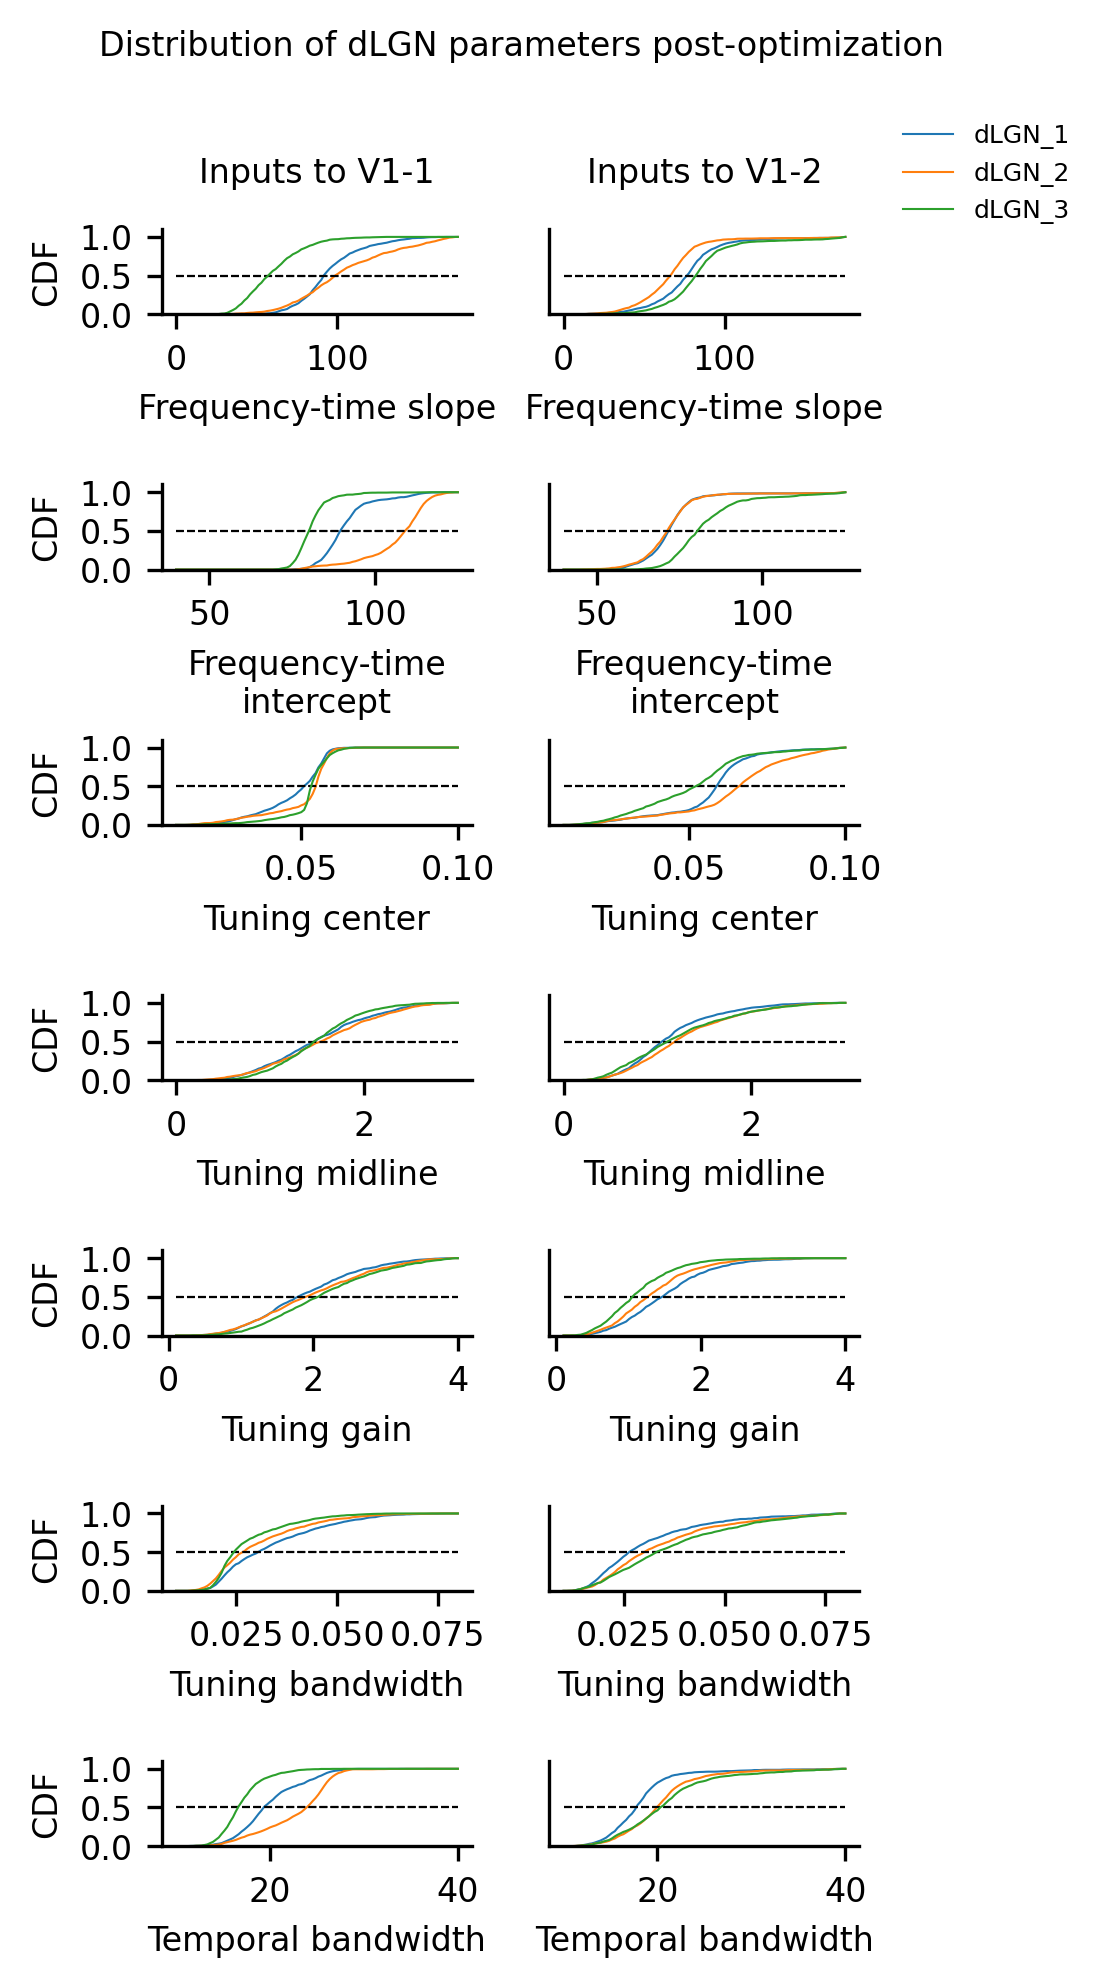

In [ ]:
fig, ax = plt.subplots(7,2, figsize = (3,7))

param_labels = [
    'Frequency-time slope',
    'Frequency-time\nintercept',
    'Tuning center',
    'Tuning midline',
    'Tuning gain',
    'Tuning bandwidth',
    'Temporal bandwidth'
]

neuron_labels = [f'dLGN_{i+1}' for i in range(3)]


for row in range(7):
    ymax = []
    for i in range(3):
        for u in range(2):
            data = param_history['dLGN_params'][:,-1,u,i,row,0,0]
            x = np.linspace(
                list(param_bounds.values())[:7][row][0],
                list(param_bounds.values())[:7][row][1], 
                100
            )
            kde = ecdf(data).cdf
            y = kde.evaluate(x)

            ymax.append(y.max())

            ax[row, u].plot(x, np.full(len(x), 0.5), '--', color = 'black', linewidth = linewidth)
            ax[row, u].plot(x, y, label = neuron_labels[i], linewidth = linewidth)
            ax[row, u].set_xlabel(param_labels[row], fontsize = fontsize)
            ax[row, u].tick_params(labelsize = fontsize)

    ax[row, 0].set_ylabel("CDF", fontsize = fontsize)
    for u in range(2):
        ax[row, u].set_ylim(0, 1.1)
        ax[row, 1].set_yticks([])
        ax[row, 0].set_yticks(np.arange(0, 1.5, 0.5))
        ax[row, u].spines['top'].set_visible(False)
        ax[row, u].spines['right'].set_visible(False)

fig.subplots_adjust(hspace = 2, wspace=0.25)
plt.tick_params(labelsize = 8)
ax[0,1].legend(fontsize = 6, bbox_to_anchor = (1.75,2.5), frameon = False)
ax[0,0].set_title("Inputs to V1-1", fontsize = fontsize, y = 1.25)
ax[0,1].set_title("Inputs to V1-2", fontsize = fontsize, y = 1.25)
plt.suptitle("Distribution of dLGN parameters post-optimization", fontsize = fontsize, x = 0.525, y = 0.975)


In [66]:
predictions = model.predict(X)

NameError: name 'model' is not defined

In [ ]:
loss_decay = optimizer.outputs['loss_decay']
last_epoch = loss_decay[-1]
best = np.where(last_epoch == last_epoch.min())[0][0]
print(f"Index of best parameters: {best}, loss = {last_epoch[best]}")

Index of best parameters: 839, loss = 0.06903076171875


In [ ]:
v1_neuron_1, v1_neuron_2 = predictions[best]

In [ ]:
low_sf_1 = v1_neuron_1[0]
high_sf_1 = v1_neuron_1[-1]

low_sf_2 = v1_neuron_2[0]
high_sf_2 = v1_neuron_2[-1]

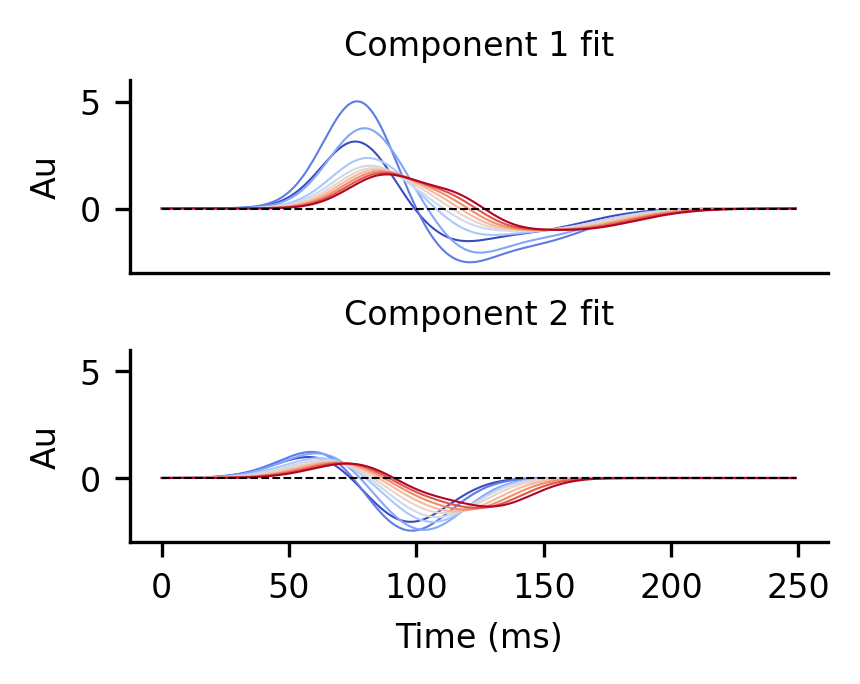

In [ ]:
cmap = plt.get_cmap('coolwarm') 
rcParams['axes.prop_cycle'] = cycler(color=cmap(np.linspace(0, 1, 10)))
fig, ax = plt.subplots(2, figsize = (3,2))

ax[0].plot(predictions[best][0].numpy().T, linewidth = linewidth)
ax[0].set_title("Component 1 fit", fontsize = fontsize)
ax[0].set_xticks([])

ax[1].plot(predictions[best][1].numpy().T, linewidth = linewidth)
ax[1].set_title('Component 2 fit', fontsize = fontsize)
for i in range(2):
    ax[i].set_ylabel("Au", fontsize = fontsize)
    ax[i].plot(np.zeros(250), '--', color = 'black', linewidth = linewidth)
    ax[i].tick_params(labelsize = fontsize)
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)
    
ax[0].set_ylim(-3,6)
ax[1].set_ylim(-3,6)
ax[1].set_xlabel("Time (ms)", fontsize = fontsize)
fig.subplots_adjust(hspace=0.4)

Text(0.5, 1.15, 'V1 Neuron 1 (High latency unit)')

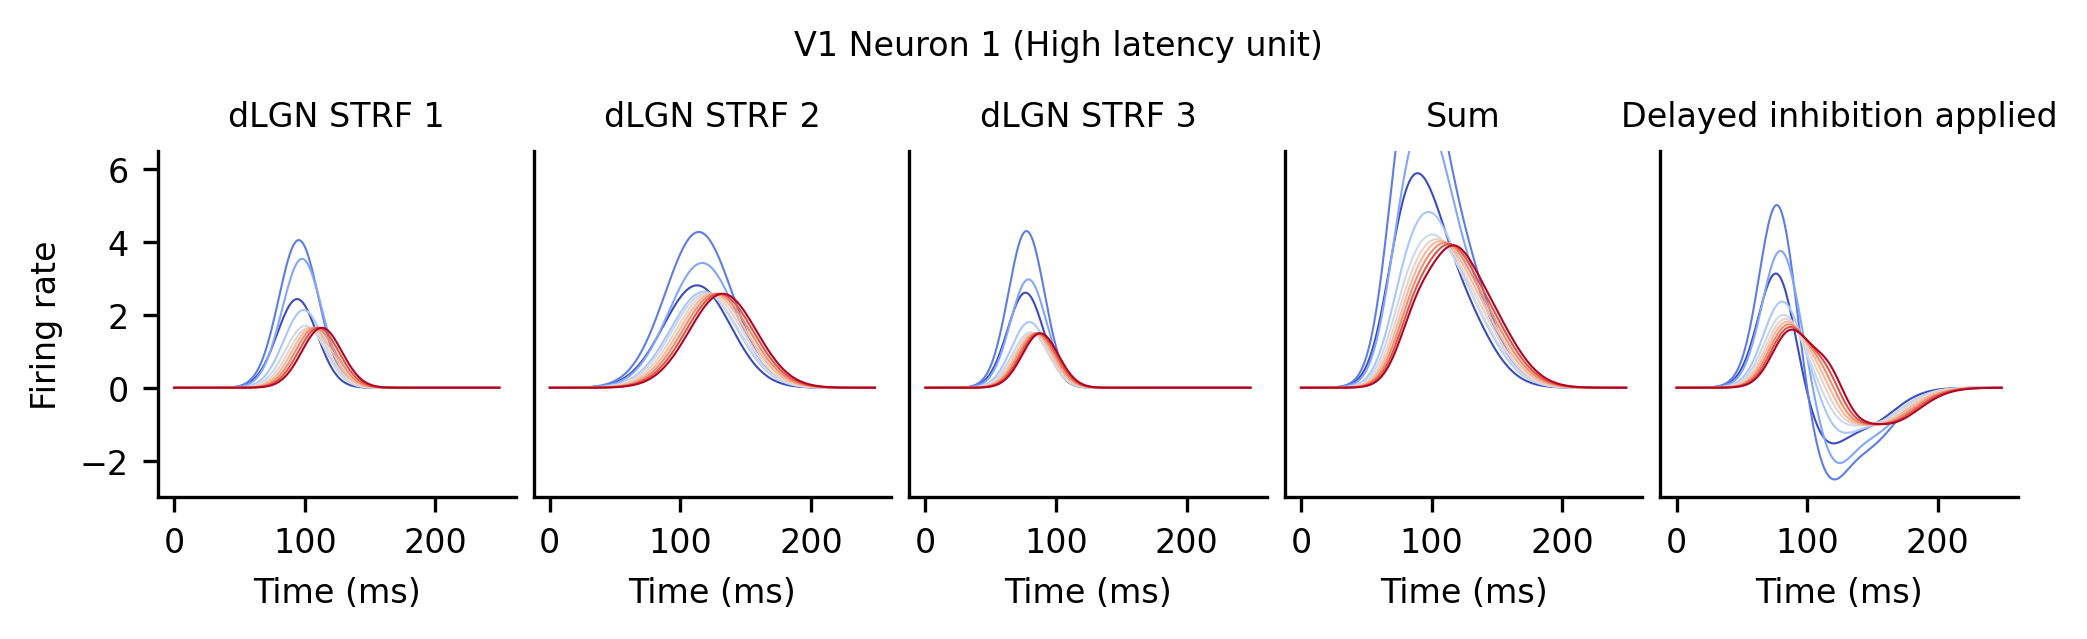

In [ ]:
cmap = plt.get_cmap('coolwarm') 
rcParams['axes.prop_cycle'] = cycler(color=cmap(np.linspace(0, 1, 10)))
fig, ax = plt.subplots(1,5, figsize = (8,1.5))

ax[0].plot(model.dlgn_exc[best][0,0].numpy().T, linewidth = linewidth)
ax[1].plot(model.dlgn_exc[best][0,1].numpy().T, linewidth = linewidth)
ax[2].plot(model.dlgn_exc[best][0,2].numpy().T, linewidth = linewidth)
ax[3].plot(model.v1_exc[best][0].numpy().T, linewidth = linewidth)
ax[4].plot(predictions[best][0].numpy().T, linewidth = linewidth)

for i in range(5):
    if i>0:
        ax[i].set_yticks([])
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)
    ax[i].tick_params(labelsize = fontsize)
    ax[i].set_ylim(-3,6.5)
    ax[i].set_xlabel("Time (ms)", fontsize = fontsize)

fig.subplots_adjust(wspace=0.05)
ax[0].set_ylabel("Firing rate", fontsize = fontsize)

ax[0].set_title("dLGN STRF 1", fontsize = fontsize)
ax[1].set_title("dLGN STRF 2", fontsize = fontsize)
ax[2].set_title("dLGN STRF 3", fontsize = fontsize)
ax[3].set_title("Sum", fontsize = fontsize)
ax[4].set_title("Delayed inhibition applied", fontsize = fontsize)

plt.suptitle("V1 Neuron 1 (High latency unit)", y = 1.15, fontsize = fontsize)

Text(0.5, 1.15, 'V1 Neuron 2 (Low latency unit)')

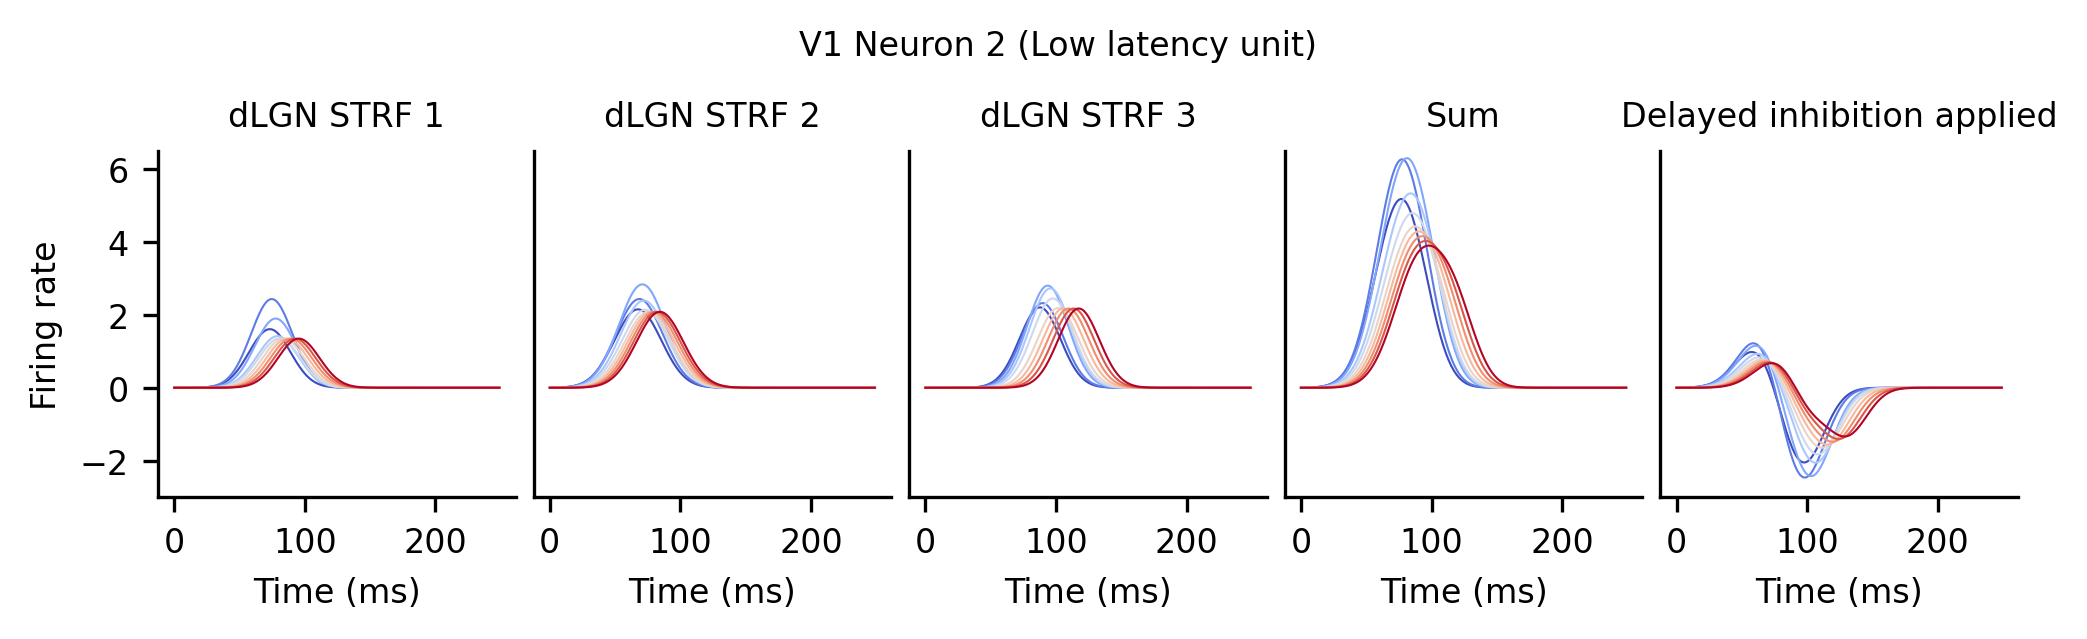

In [ ]:
cmap = plt.get_cmap('coolwarm') 
rcParams['axes.prop_cycle'] = cycler(color=cmap(np.linspace(0, 1, 10)))
fig, ax = plt.subplots(1,5, figsize = (8,1.5))

ax[0].plot(model.dlgn_exc[best][1,0].numpy().T, linewidth = linewidth)
ax[1].plot(model.dlgn_exc[best][1,1].numpy().T, linewidth = linewidth)
ax[2].plot(model.dlgn_exc[best][1,2].numpy().T, linewidth = linewidth)
ax[3].plot(model.v1_exc[best][1].numpy().T, linewidth = linewidth)
ax[4].plot(predictions[best][1].numpy().T, linewidth = linewidth)

for i in range(5):
    if i>0:
        ax[i].set_yticks([])
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)
    ax[i].tick_params(labelsize = fontsize)
    ax[i].set_ylim(-3,6.5)
    ax[i].set_xlabel("Time (ms)", fontsize = fontsize)

fig.subplots_adjust(wspace=0.05)
ax[0].set_ylabel("Firing rate", fontsize = fontsize)

ax[0].set_title("dLGN STRF 1", fontsize = fontsize)
ax[1].set_title("dLGN STRF 2", fontsize = fontsize)
ax[2].set_title("dLGN STRF 3", fontsize = fontsize)
ax[3].set_title("Sum", fontsize = fontsize)
ax[4].set_title("Delayed inhibition applied", fontsize = fontsize)

plt.suptitle("V1 Neuron 2 (Low latency unit)", y = 1.15, fontsize = fontsize)